In [1]:
from sklearn.svm import SVC
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
from sklearn import svm

In [2]:
raw_data=pd.read_excel("main_data.xlsx")
raw_data.head(5)

,EWO No,Responsiveness,Co_operativeness,Packaging,Order Date,Consistency,Item Name,On time Delivery,Delivery Performance,Fineness,...,Flexibility,Order Fullfillment,Delivery Date,Vendor,Supplier Address,After sale servixe,Total Qty in (Kg),Total Price,Lead Time,Unit price
0,22 19 01 000001,5,4,3,43461,4,Jute Yarn,1,4,3,...,3,0,2018-12-27,V29,"Plot-I/5, I/7, I/9, I/11 & I/13, Road-6, Secti...",5,10.343222,25.0997,0,2.426681
1,22 19 01 000001,5,4,3,43461,4,Jute Yarn,1,4,3,...,3,0,2018-12-27,V29,"Plot-I/5, I/7, I/9, I/11 & I/13, Road-6, Secti...",5,41.561100,100.7772,0,2.424796
2,22 19 01 000002,3,1,3,43466,4,Jute Yarn,1,4,3,...,4,1,2019-01-05,V47,"126/1,Kadda Nandun, Kadda Bazar, Gazipur Sadar...",5,81.647464,153.0000,4,1.873910
3,22 19 01 000002,3,1,3,43466,4,Jute Yarn,1,4,3,...,4,1,2019-01-05,V47,"126/1,Kadda Nandun, Kadda Bazar, Gazipur Sadar...",5,10.026309,18.7884,4,1.873910
4,22 19 01 000002,3,1,3,43466,4,Jute Yarn,1,4,3,...,4,1,2019-01-05,V47,"126/1,Kadda Nandun, Kadda Bazar, Gazipur Sadar...",5,12.181802,22.8276,4,1.873910


In [3]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7720 entries, 0 to 7719
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   EWO No                7720 non-null   object        
 1   Responsiveness        7720 non-null   int64         
 2   Co_operativeness      7720 non-null   int64         
 3   Packaging             7720 non-null   int64         
 4   Order Date            7720 non-null   int64         
 5   Consistency           7720 non-null   int64         
 6   Item Name             7720 non-null   object        
 7   On time Delivery      7720 non-null   int64         
 8   Delivery Performance  7720 non-null   int64         
 9   Fineness              7720 non-null   int64         
 10  Length(cm)            7720 non-null   float64       
 11  Strength (gm/denier)  7720 non-null   float64       
 12  Flexibility           7720 non-null   int64         
 13  Order Fullfillment

In [4]:
frequency_table = raw_data["Vendor"].value_counts()
frequency_df = pd.DataFrame(frequency_table).reset_index()

# Rename the columns for clarity
frequency_df.columns = ['Vendor', 'Frequency']

In [5]:
frequency_df[:46]

,Vendor,Frequency
0,V80,751
1,V27,716
2,V55,469
3,V28,469
4,V39,413
5,V85,404
6,V68,340
7,V40,216
8,V13,200
9,V75,195


In [6]:
vendors_with_min_frequency = frequency_table[frequency_table >= 35].index.tolist()

In [7]:
len(vendors_with_min_frequency)

46

In [8]:
filtered_data = raw_data[raw_data["Vendor"].isin(vendors_with_min_frequency)]
len(filtered_data)

7055

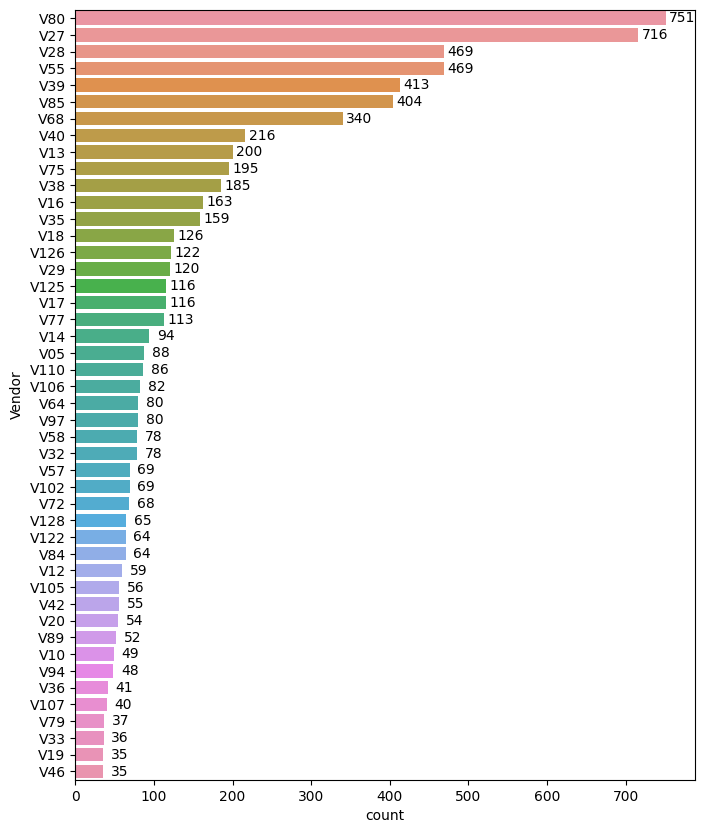

In [9]:
plt.figure(figsize=(8, 10))

# Create the countplot with bars sorted in descending order
ax = sns.countplot(y=filtered_data["Vendor"], order=filtered_data["Vendor"].value_counts().index)

# Annotate each bar with its exact value
for p in ax.patches:
    ax.annotate(format(p.get_width(), '.0f'), 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'center', va = 'center', 
                 xytext = (12, 0), 
                 textcoords = 'offset points')

plt.show()

In [10]:
filtered_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Responsiveness,7055.0,4.370801,0.723848,3.000000,4.000000,5.000000,5.000000,5.000000
Co_operativeness,7055.0,3.499787,1.092007,1.000000,3.000000,4.000000,4.000000,5.000000
Packaging,7055.0,3.040539,0.316005,1.000000,3.000000,3.000000,3.000000,5.000000
Order Date,7055.0,43649.923459,110.968918,43461.000000,43556.000000,43638.000000,43754.000000,43830.000000
Consistency,7055.0,3.919206,0.438757,1.000000,4.000000,4.000000,4.000000,5.000000
On time Delivery,7055.0,0.957619,0.201472,0.000000,1.000000,1.000000,1.000000,1.000000
Delivery Performance,7055.0,3.711127,0.831176,1.000000,3.000000,4.000000,4.000000,5.000000
Fineness,7055.0,4.289157,1.042622,1.000000,3.000000,5.000000,5.000000,5.000000
Length(cm),7055.0,189.385942,52.573376,109.862205,146.023622,175.610236,227.254000,354.508000
Strength (gm/denier),7055.0,5.065512,0.320466,3.850000,4.900000,5.250000,5.250000,7.000000


In [11]:
outliers=[]
def detect_outlier(data_1):
    outliers=[]
    threshold=3
    mean_1 = np.mean(data_1)
    std_1 =np.std(data_1)
    
    
    for y in data_1:
        z_score= (y - mean_1)/std_1 
        if np.abs(z_score) > threshold:
            outliers.append(y)
    return outliers

In [12]:
value = set(filtered_data['Vendor'])
for i in value:
    print(i)
    filtered_data_2=filtered_data[filtered_data['Vendor'] == i]
    dataset=filtered_data_2['Length(cm)']
    outlier_datapoints = detect_outlier(dataset)
    for j in outlier_datapoints:
        filtered_data_2 = filtered_data[(filtered_data['Vendor'] == i) & (filtered_data['Length(cm)'] == j)]
        filtered_data.drop(filtered_data_2.index, inplace=True)

V17
V33
V05
V107
V122
V40
V10
V12
V77
V57
V106
V39
V85
V19
V68
V55
V97
V16
V38
V80
V64
V110
V84
V75
V105
V94
V46
V102


C:\Users\Proven\AppData\Local\Temp\ipykernel_10444\4050813565.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(filtered_data_2.index, inplace=True)


V29
V27
V20
V72
V32
V42
V18
V58
V126
V28
V35
V14
V79
V13
V128
V36
V89
V125


In [13]:
len(filtered_data)

7001

In [14]:

value = set(filtered_data['Vendor'])
for i in value:
    print(i)
    filtered_data_2=filtered_data[filtered_data['Vendor'] == i]
    dataset=filtered_data_2['Strength (gm/denier)']
    outlier_datapoints = detect_outlier(dataset)
    for j in outlier_datapoints:
        filtered_data_2 = filtered_data[(filtered_data['Vendor'] == i) & (filtered_data['Strength (gm/denier)'] == j)]
        filtered_data.drop(filtered_data_2.index, inplace=True)


V17
V33
V05
V107
V122
V40
V10
V12
V77
V57
V106
V39
V85
V19
V68
V55
V97
V16
V38
V80
V64
V110
V84


C:\Users\Proven\AppData\Local\Temp\ipykernel_10444\350193913.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(filtered_data_2.index, inplace=True)
C:\Users\Proven\AppData\Local\Temp\ipykernel_10444\1540775322.py:10: RuntimeWarning: invalid value encountered in scalar divide
  z_score= (y - mean_1)/std_1


V75
V105
V94
V46
V102
V29
V27
V20
V72
V32
V42
V18
V58
V126
V28
V35
V14
V79
V13
V128
V36
V89
V125


In [15]:
len(filtered_data)

6883

In [16]:

for i in value:
    print(i)
    filtered_data_2=filtered_data[filtered_data['Vendor'] == i]
    dataset=filtered_data_2['Unit price']
    outlier_datapoints = detect_outlier(dataset)
    for j in outlier_datapoints:
        filtered_data_2 = filtered_data[(filtered_data['Vendor'] == i) & (filtered_data['Unit price'] == j)]
        filtered_data.drop(filtered_data_2.index, inplace=True)


V17
V33
V05
V107
V122
V40
V10
V12
V77
V57
V106
V39
V85
V19
V68
V55
V97
V16
V38
V80
V64


C:\Users\Proven\AppData\Local\Temp\ipykernel_10444\1693463254.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(filtered_data_2.index, inplace=True)


V110
V84
V75
V105
V94
V46
V102
V29
V27
V20
V72
V32
V42
V18
V58
V126
V28
V35
V14
V79
V13
V128
V36
V89
V125


In [17]:
len(filtered_data)
filtered_data.dropna(inplace=True)
len(filtered_data)

C:\Users\Proven\AppData\Local\Temp\ipykernel_10444\3518902970.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.dropna(inplace=True)


6784

In [18]:
filtered_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Responsiveness,6784.0,4.370283,0.722202,3.000000,4.000000,5.000000,5.000000,5.000000
Co_operativeness,6784.0,3.502506,1.094661,1.000000,3.000000,4.000000,4.000000,5.000000
Packaging,6784.0,3.041863,0.317115,1.000000,3.000000,3.000000,3.000000,5.000000
Order Date,6784.0,43650.434404,111.428784,43461.000000,43556.000000,43640.000000,43757.000000,43830.000000
Consistency,6784.0,3.924528,0.425724,1.000000,4.000000,4.000000,4.000000,5.000000
On time Delivery,6784.0,0.957989,0.200628,0.000000,1.000000,1.000000,1.000000,1.000000
Delivery Performance,6784.0,3.704599,0.833298,1.000000,3.000000,4.000000,4.000000,5.000000
Fineness,6784.0,4.306014,1.039023,1.000000,3.000000,5.000000,5.000000,5.000000
Length(cm),6784.0,188.905915,51.630814,109.862205,146.023622,172.322835,227.254000,354.508000
Strength (gm/denier),6784.0,5.069260,0.312247,3.850000,4.900000,5.250000,5.250000,7.000000


In [19]:
summary_stats = filtered_data.describe().T


In [20]:
summary_stats.loc["Responsiveness", "std"]

0.7222020906492418

C:\Users\Proven\AppData\Local\Temp\ipykernel_10444\889654783.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corrmat = m_filtered_data.corr()


<Axes: >

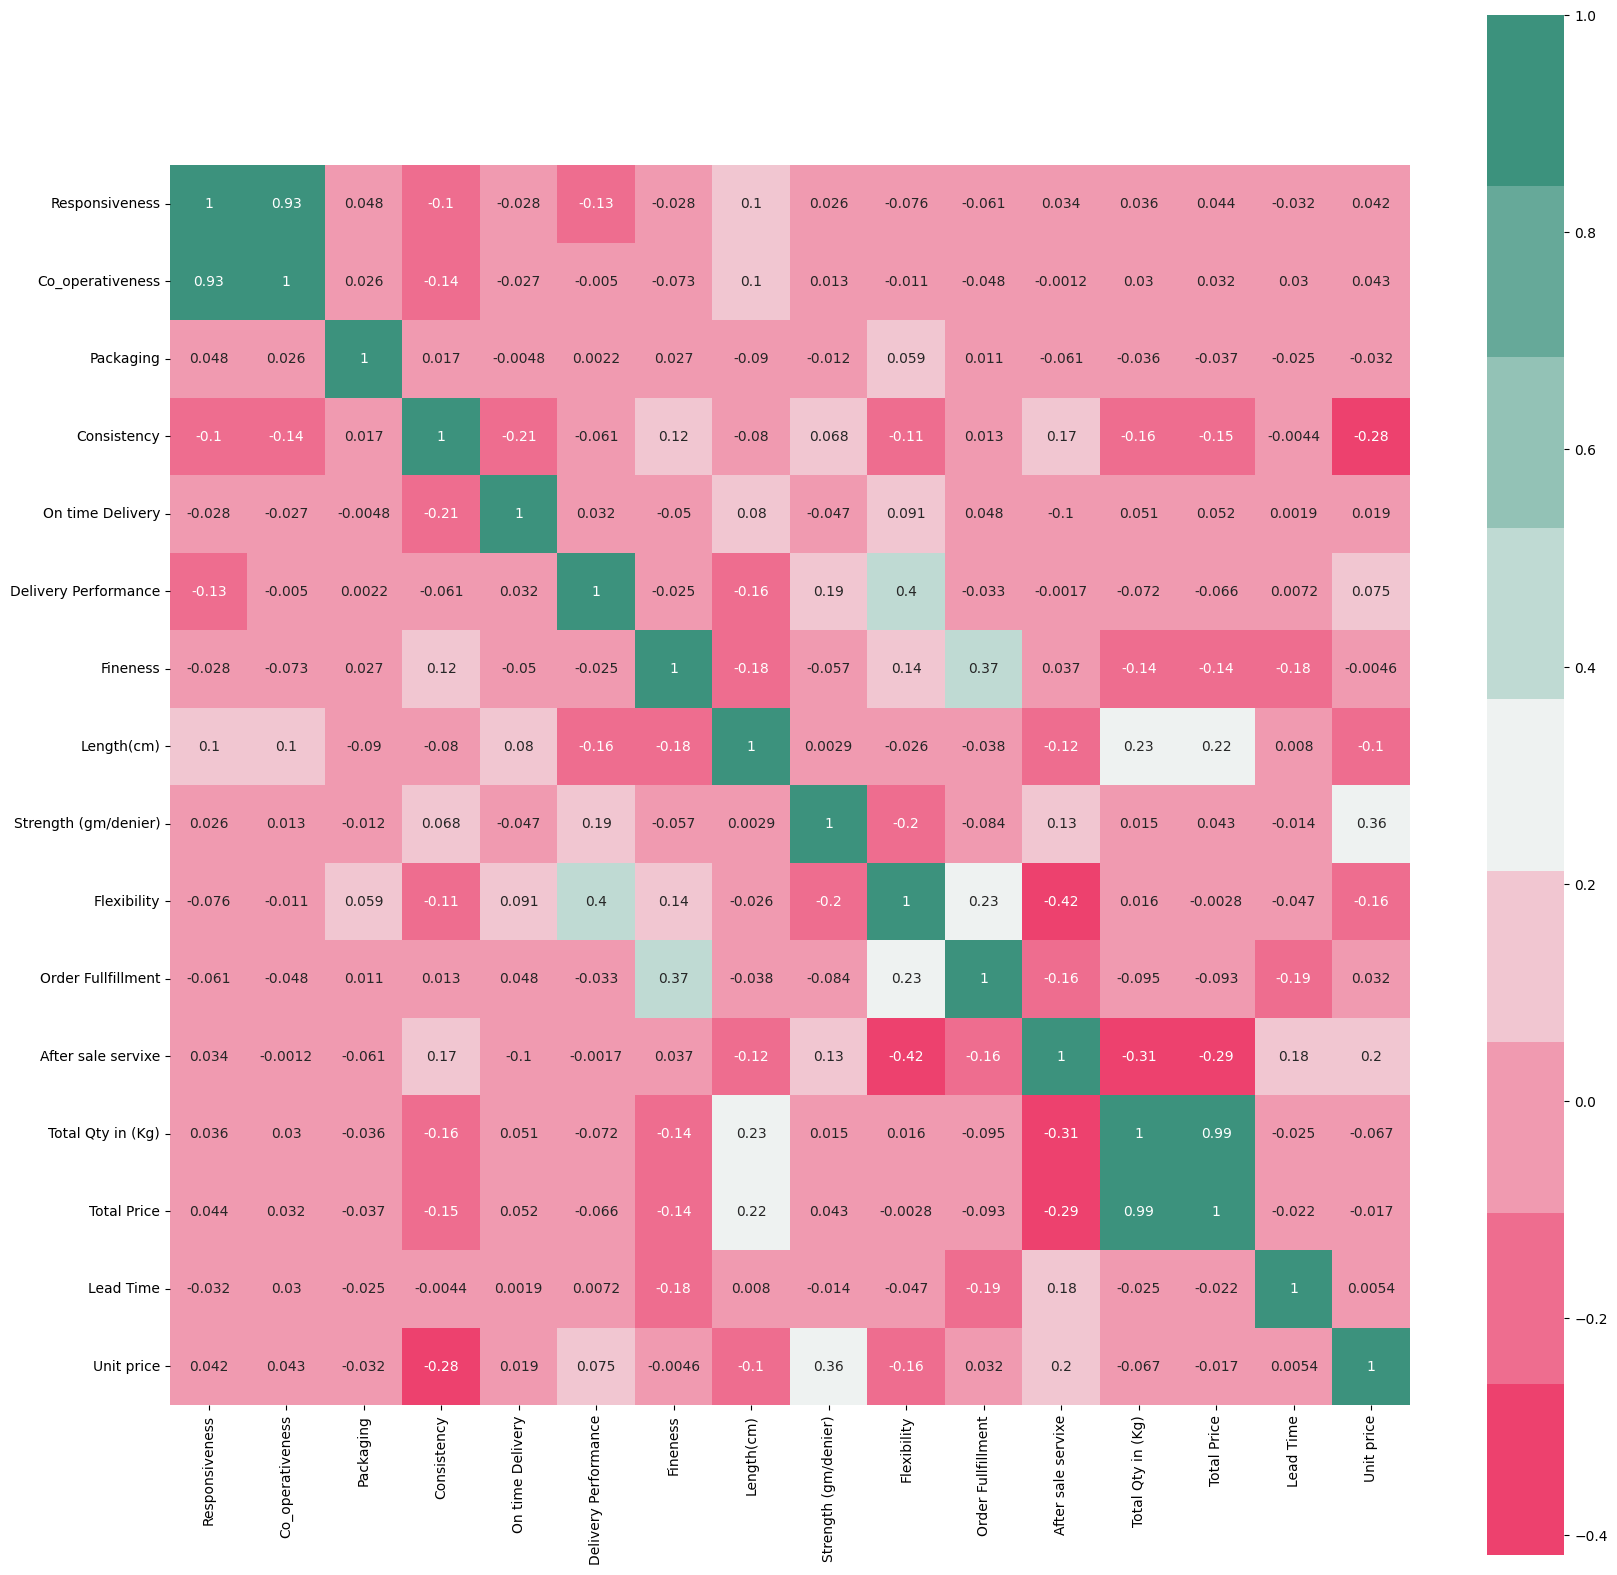

In [21]:
cmap = sns.diverging_palette(2, 165, s=80, l=55, n=9)
m_filtered_data=filtered_data.drop(columns=['Item Name', 'EWO No', 'Order Date','Delivery Date','Supplier Address'])
corrmat = m_filtered_data.corr()
plt.subplots(figsize=(20,20))
sns.heatmap(corrmat,cmap= cmap,annot=True, square=True)

In [22]:
X=m_filtered_data.drop(columns=['Vendor'])
y=m_filtered_data['Vendor']
y = y.str.replace('V', '')
y = y.astype(int)

In [23]:
X.head(49)

,Responsiveness,Co_operativeness,Packaging,Consistency,On time Delivery,Delivery Performance,Fineness,Length(cm),Strength (gm/denier),Flexibility,Order Fullfillment,After sale servixe,Total Qty in (Kg),Total Price,Lead Time,Unit price
0,5,4,3,4,1,4,3,184.836000,5.250,3,0,5,10.343222,25.0997,0,2.426681
1,5,4,3,4,1,4,3,193.319600,5.250,3,0,5,41.561100,100.7772,0,2.424796
11,4,3,3,4,1,4,3,206.045000,5.250,3,0,5,8.089147,19.6238,2,2.425942
12,4,3,3,4,1,4,3,189.077800,5.250,3,0,5,4.005806,9.7110,22,2.424231
13,4,3,3,4,1,4,3,206.045000,5.250,3,0,5,10.363180,25.1214,22,2.424101
14,4,3,3,4,1,4,3,227.254000,5.250,3,0,5,4.969609,12.0516,13,2.425060
15,4,3,3,4,1,4,3,193.319600,5.250,3,0,5,60.124951,145.8340,25,2.425515
16,4,3,3,4,1,4,3,265.430200,5.250,3,0,5,100.952554,244.8160,25,2.425060
17,4,3,3,4,1,4,3,193.319600,5.250,3,0,5,10.625782,25.7730,0,2.425515
18,4,3,3,4,1,4,3,261.188400,5.250,3,0,5,6.343101,15.3870,0,2.425785


In [24]:
col_names = list(X.columns)
s_scaler = preprocessing.StandardScaler()
X_scaled= s_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=col_names)   
# summary_stats = X_scaled.describe().T

In [25]:
summary_stats.loc["Responsiveness", "mean"]

4.370283018867925

In [27]:
X_train, X_test, y_train,y_test = train_test_split(X_scaled,y,test_size=0.25,random_state=25)

In [28]:
X_train.head(49)

,Responsiveness,Co_operativeness,Packaging,Consistency,On time Delivery,Delivery Performance,Fineness,Length(cm),Strength (gm/denier),Flexibility,Order Fullfillment,After sale servixe,Total Qty in (Kg),Total Price,Lead Time,Unit price
1423,0.872004,1.368098,-0.132022,0.177291,0.209411,1.554662,-0.294543,-0.407483,-1.663102,1.411646,0.912698,-0.659148,-0.168088,-0.135685,-0.935368,0.202257
5014,-0.512752,-0.459085,-0.132022,0.177291,0.209411,0.354522,0.667971,-1.110792,0.578878,-0.884902,-1.095652,0.754592,0.196778,0.328475,-0.471479,0.305999
5062,-0.512752,-0.459085,-0.132022,0.177291,0.209411,0.354522,0.667971,-1.072586,1.699868,0.263372,0.912698,0.754592,-0.397355,-0.409237,-0.239535,0.279276
4090,0.872004,0.454507,-0.132022,0.177291,0.209411,-0.845617,0.667971,-0.703265,0.578878,-0.884902,0.912698,-2.072889,0.036050,0.041306,-0.239535,-0.139691
5145,-0.512752,-0.459085,-0.132022,0.177291,0.209411,0.354522,0.667971,0.249817,0.578878,-0.884902,0.912698,0.754592,-0.344284,-0.343978,-0.239535,0.279166
6040,-0.512752,-0.459085,-0.132022,0.177291,0.209411,0.354522,0.667971,-0.703265,-2.223597,0.263372,0.912698,0.754592,-0.357898,-0.354833,-0.007590,0.496997
6729,-0.512752,-0.459085,-0.132022,0.177291,0.209411,0.354522,0.667971,-0.766941,-2.223597,0.263372,0.912698,0.754592,-0.190290,-0.132603,-0.471479,0.501071
5659,-0.512752,-0.459085,-0.132022,0.177291,0.209411,0.354522,0.667971,-0.919764,0.578878,-0.884902,-1.095652,0.754592,-0.146446,-0.102776,-0.471479,0.261640
4666,0.872004,0.454507,-0.132022,-2.171820,0.209411,-0.845617,-0.294543,-0.830617,0.578878,-0.884902,-1.095652,-2.072889,-0.353884,-0.364377,0.456299,-0.019783
3467,0.872004,0.454507,-0.132022,0.177291,0.209411,0.354522,-1.257056,1.646578,0.578878,-0.884902,-1.095652,0.754592,-0.337294,-0.338095,-0.007590,0.203635


In [29]:

model1 = svm.SVC(C=10, degree=3)

# Fit the model
model1.fit(X_train, y_train)

# Predict the test variables
y_pred = model1.predict(X_test)

# Get the score
score = model1.score(X_test, y_test)
print(f"Model Score: {score}")


Model Score: 0.9339622641509434


In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, and F1 score for a multi-class classification
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Precision: 0.933151742891267
Recall: 0.9339622641509434
F1 Score: 0.9265115349309951


In [32]:
import numpy as np

# Calculate number of correct predictions
correct_predictions = np.sum(y_test == y_pred)

# Calculate number of incorrect predictions (failures)
incorrect_predictions = np.sum(y_test != y_pred)

print(f"Correct Predictions: {correct_predictions}")
print(f"Incorrect Predictions: {incorrect_predictions}")


Correct Predictions: 1584
Incorrect Predictions: 112


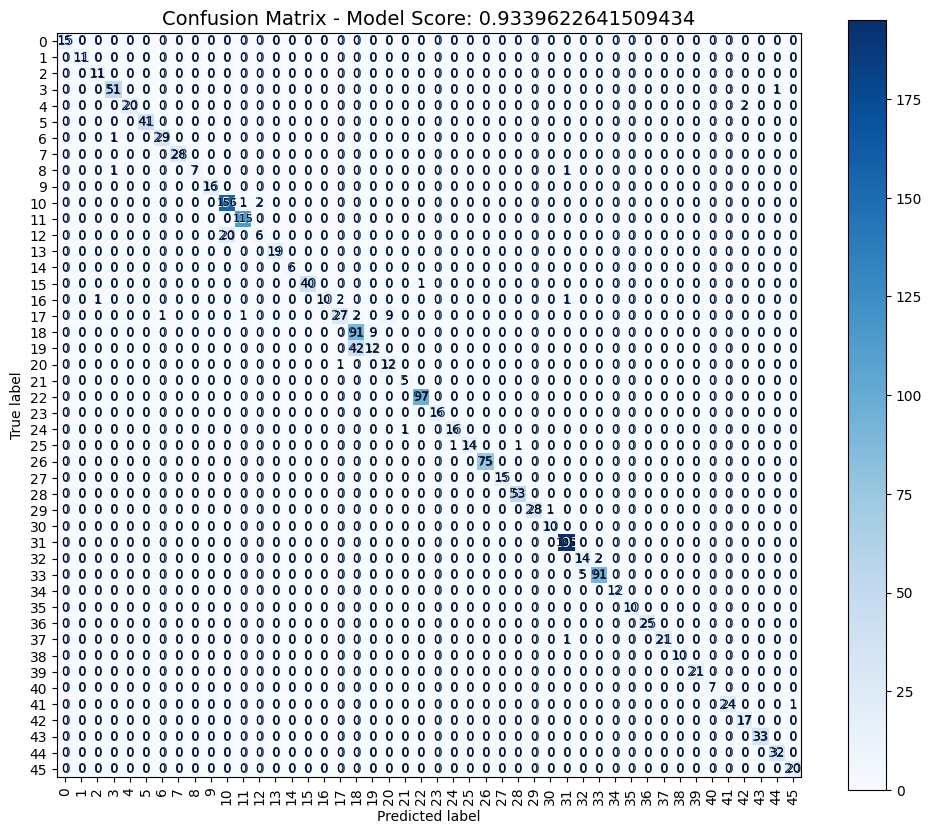

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming you already have the predictions (y_pred) and the true labels (y_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Set a larger figure size
plt.figure(figsize=(12, 10))

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=plt.gca())

# Set the title of the plot
plt.title(f"Confusion Matrix - Model Score: {score}", fontsize=14)

# Modify the x-axis labels to be vertical and set font size
plt.xticks(rotation=90, fontsize=10)  # Change 10 to your desired font size
plt.yticks(fontsize=10)  # Set y-axis font size

# Adjust the size of the internal numbers
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # Use a slightly larger font size for internal numbers for better readability
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8, color='black')  # Set font size for internal numbers

# Add gridlines for better separation
plt.grid(False)

# Show the plot
plt.show()


C:\Users\Proven\AppData\Local\Temp\ipykernel_13648\4278554421.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


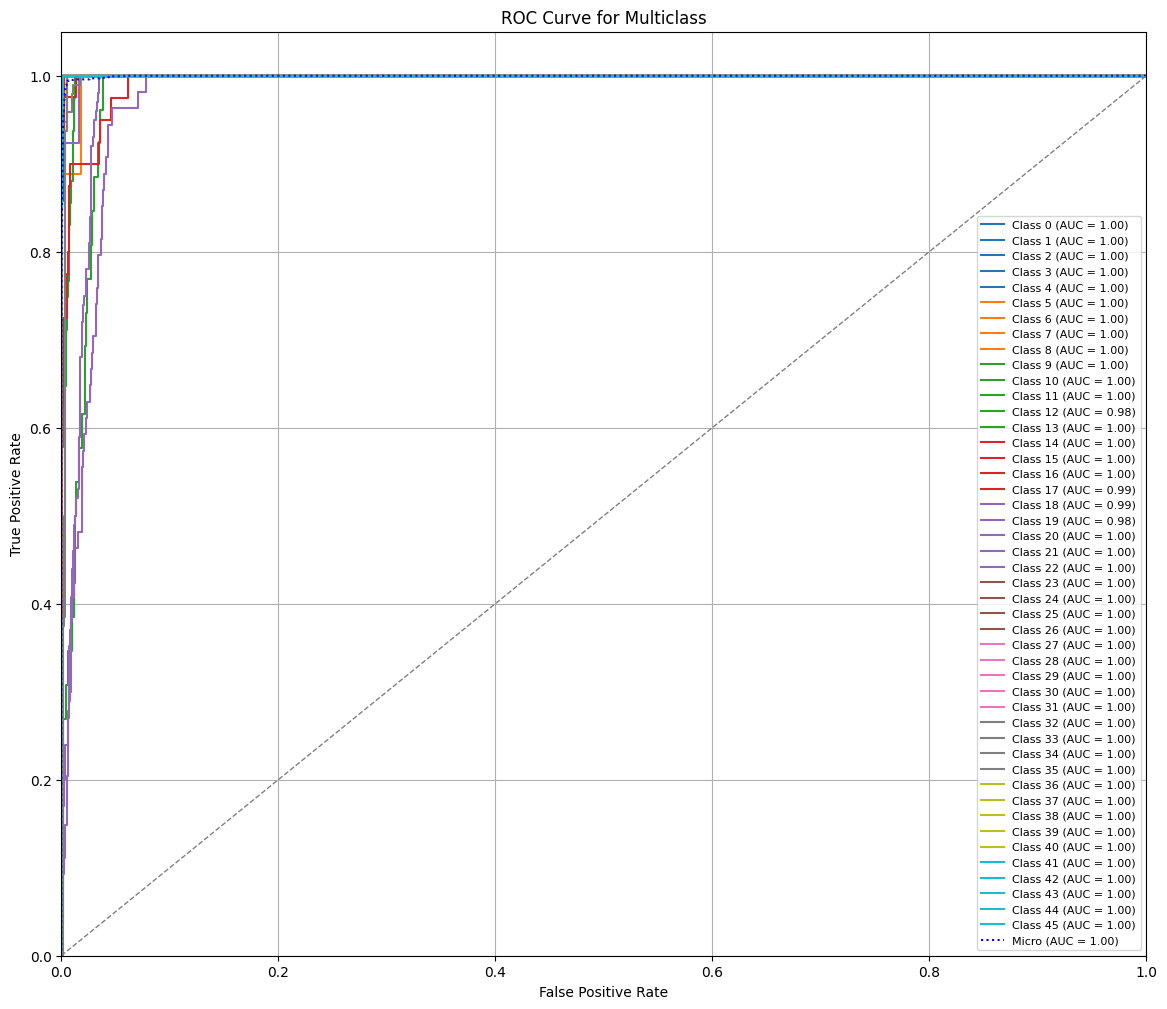

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Fit your SVM model (if not already fitted)
model1 = svm.SVC(C=10, degree=3, probability=True)
model1.fit(X_train, y_train)

# Get predicted probabilities for all classes
y_prob = model1.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure(figsize=(14, 12))
colors = plt.cm.get_cmap('tab10', n_classes)

# Plot each class's ROC curve
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=1.5, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"], color='blue', linestyle=':', linewidth=1.5, label=f'Micro (AUC = {roc_auc["micro"]:.2f})')

# Plotting the diagonal line for random chance
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=10)
plt.ylabel('True Positive Rate', fontsize=10)
plt.title('ROC Curve for Multiclass', fontsize=12)
plt.legend(loc='lower right', fontsize=8)
plt.grid()
plt.show()


In [35]:
# Instantiating the Random Forest Classifier
model2 = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust parameters like n_estimators, max_depth, etc.

# Fitting the model
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)

# Get the score
score = model2.score(X_test, y_test)
print(f"Model Score: {score}")

Model Score: 0.9575471698113207


In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, and F1 score for a multi-class classification
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Precision: 0.9576033107994013
Recall: 0.9575471698113207
F1 Score: 0.9558765446337443


In [37]:
import numpy as np

# Calculate number of correct predictions
correct_predictions = np.sum(y_test == y_pred)

# Calculate number of incorrect predictions (failures)
incorrect_predictions = np.sum(y_test != y_pred)

print(f"Correct Predictions: {correct_predictions}")
print(f"Incorrect Predictions: {incorrect_predictions}")

Correct Predictions: 1624
Incorrect Predictions: 72


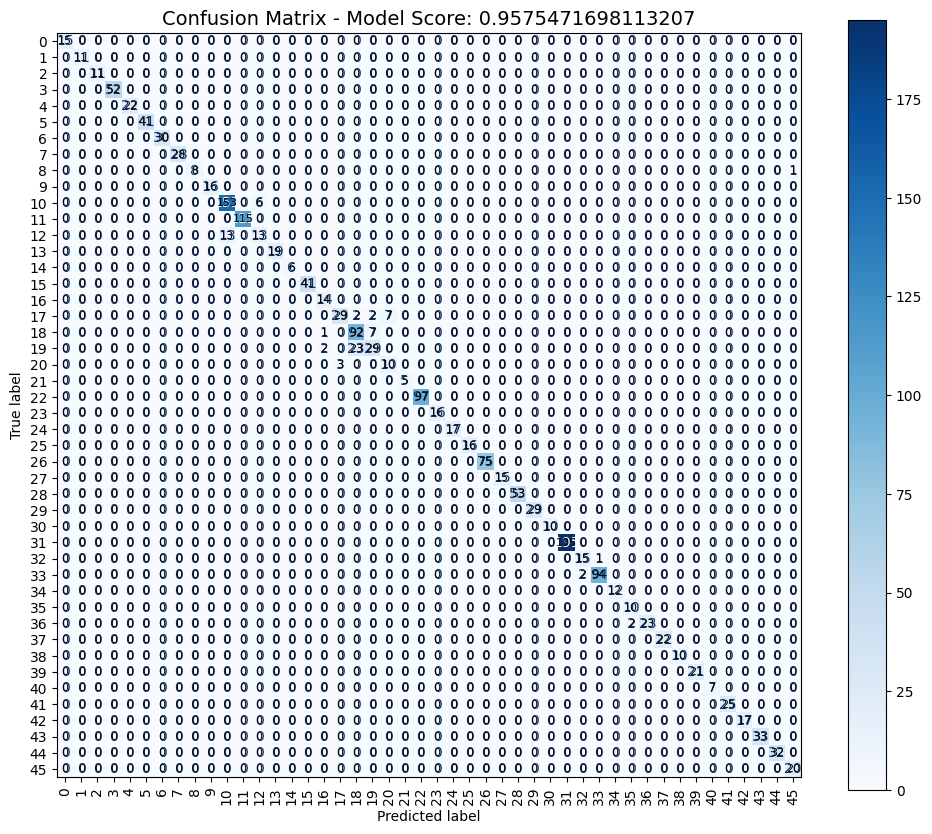

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming you already have the predictions (y_pred) and the true labels (y_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Set a larger figure size
plt.figure(figsize=(12, 10))

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=plt.gca())

# Set the title of the plot
plt.title(f"Confusion Matrix - Model Score: {score}", fontsize=14)

# Modify the x-axis labels to be vertical and set font size
plt.xticks(rotation=90, fontsize=10)  # Change 10 to your desired font size
plt.yticks(fontsize=10)  # Set y-axis font size

# Adjust the size of the internal numbers
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # Use a slightly larger font size for internal numbers for better readability
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8, color='black')  # Set font size for internal numbers

# Add gridlines for better separation
plt.grid(False)

# Show the plot
plt.show()


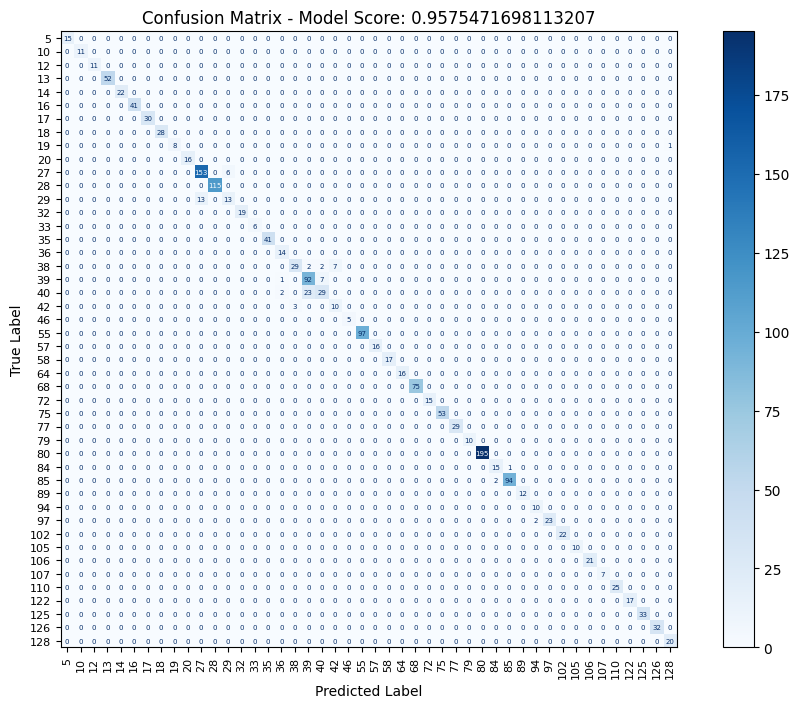

In [124]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming you already have the predictions (y_pred) and the true labels (y_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get the unique labels from the true labels
labels = sorted(y_test.unique())

# Set a larger figure size
fig, ax = plt.subplots(figsize=(12, 8))

# Display the confusion matrix with actual class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, values_format='d')

# Adjust font sizes for the labels and title
ax.set_title(f"Confusion Matrix - Model Score: {score}", fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=10)
ax.set_ylabel('True Label', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)

# Rotate x-axis labels vertically
plt.xticks(rotation=90)

# Adjust font sizes for the internal text
for text in ax.texts:
    text.set_fontsize(5)

plt.show()


In [125]:
model2.fit(X_scaled,y)

RandomForestClassifier(random_state=42)

In [126]:
import math
sg=int(input("How many suggestions do you want?"))
res=int(input("Enter the value of responsivenes[1~5]"))
res=(res-summary_stats.loc["Responsiveness", "mean"])/summary_stats.loc["Responsiveness", "std"]

coop=int(input("Enter the value of Cooperativeness[1~5]"))
coop=(coop-summary_stats.loc["Co_operativeness", "mean"])/summary_stats.loc["Co_operativeness", "std"]

pack=int(input("Enter the value of packaging[1~5]"))
pack=(pack-summary_stats.loc["Packaging", "mean"])/summary_stats.loc["Packaging", "std"]

con=int(input("Enter the value of consistency[1~5]"))
con=(con-summary_stats.loc["Consistency", "mean"])/summary_stats.loc["Consistency", "std"]


ont = int(input("Enter the value of On Time Delivery [0/1]: "))
ont = (ont - summary_stats.loc["On time Delivery", "mean"]) / summary_stats.loc["On time Delivery", "std"]

dlp = int(input("Enter the value of Delivery Performance [1~5]: "))
dlp = (dlp - summary_stats.loc["Delivery Performance", "mean"]) / summary_stats.loc["Delivery Performance", "std"]

fin = int(input("Enter the value of Fineness [1~5]: "))
fin = (fin - summary_stats.loc["Fineness", "mean"]) / summary_stats.loc["Fineness", "std"]

leng = float(input("Enter the value of yarn Length in cm: "))


strn = float(input("Enter the value of yarn Strength in gm/denier: "))


flex = int(input("Enter the value of Flexibility [1~5]: "))
flex = (flex - summary_stats.loc["Flexibility", "mean"]) / summary_stats.loc["Flexibility", "std"]

odf = int(input("Enter the value of Order Fulfillment [0/1]: "))
odf = (odf - summary_stats.loc["Order Fullfillment", "mean"]) / summary_stats.loc["Order Fullfillment", "std"]

afs = int(input("Enter the value of After Sale Service [1~5]: "))
afs = (afs - summary_stats.loc["After sale servixe", "mean"]) / summary_stats.loc["After sale servixe", "std"]

qnt = int(input("Enter the value of Quantity: "))


unt = float(input("Enter the value of Unit Price: "))


ltd = int(input("Enter the value of Lead Time: "))

How many suggestions do you want?5
Enter the value of responsivenes[1~5]5
Enter the value of Cooperativeness[1~5]5
Enter the value of packaging[1~5]5
Enter the value of consistency[1~5]5
Enter the value of On Time Delivery [0/1]: 1
Enter the value of Delivery Performance [1~5]: 5
Enter the value of Fineness [1~5]: 5
Enter the value of yarn Length in cm: 110
Enter the value of yarn Strength in gm/denier: 4
Enter the value of Flexibility [1~5]: 5
Enter the value of Order Fulfillment [0/1]: 1
Enter the value of After Sale Service [1~5]: 5
Enter the value of Quantity: 60
Enter the value of Unit Price: 2
Enter the value of Lead Time: 5


In [130]:
res=int(input("Enter the value of responsivenes[1~5]"))
res=(res-summary_stats.loc["Responsiveness", "mean"])/summary_stats.loc["Responsiveness", "std"]
con=int(input("Enter the value of consistency[1~5]"))
con=(con-summary_stats.loc["Consistency", "mean"])/summary_stats.loc["Consistency", "std"]

Enter the value of responsivenes[1~5]4
Enter the value of consistency[1~5]3


In [127]:
pack

6.174850647260728

In [132]:
res,coop,pack,con,ont,dlp,fin,leng,strn,flex,odf,tp,afs,qnt,ltd,unt

(-0.5127138562213929,
 1.3679975520696077,
 6.174850647260728,
 -2.171660071672826,
 0.20939540654100502,
 1.5545471640793453,
 0.6679215698344667,
 110.0,
 4.0,
 1.411541827770858,
 0.9126309832740376,
 4424.780787269535,
 0.7545367683721175,
 60,
 5,
 2.0)

In [128]:
res,coop,pack,con,ont,dlp,fin,leng,strn,flex,odf,tp,afs,qnt,ltd,unt

(0.8719401249115402,
 1.3679975520696077,
 6.174850647260728,
 2.5262168180683897,
 0.20939540654100502,
 1.5545471640793453,
 0.6679215698344667,
 110.0,
 4.0,
 1.411541827770858,
 0.9126309832740376,
 0.41646648098114014,
 0.7545367683721175,
 60,
 5,
 2.0)

In [131]:

results=[]
unique_results = set()
for a in range(10000):
    if a % 2 == 0:
        leng1=leng
        leng1 -= a * (51.630814 / 100)
        leng2 = (leng1 - summary_stats.loc["Length(cm)", "mean"]) / summary_stats.loc["Length(cm)", "std"]
        
        strn1=strn
        strn1 -= a * (0.312247 / 100)
        strn2 = (strn1 - summary_stats.loc["Strength (gm/denier)", "mean"]) / summary_stats.loc["Strength (gm/denier)", "std"]
        
        qnt1=qnt
        qnt1 -= a * (134.504297 / 100)
        qnt2 = (qnt1 - summary_stats.loc["Total Qty in (Kg)", "mean"]) / summary_stats.loc["Total Qty in (Kg)", "std"]
        
        unt1=unt
        unt1 -= a * (0.872881 / 100)
        unt2 = (unt1 - summary_stats.loc["Unit price", "mean"]) / summary_stats.loc["Unit price", "std"]
        
        ltd1=ltd
        ltd1 -= a * (4.3116941 / 100)
        ltd2 = (ltd1 - summary_stats.loc["Lead Time", "mean"]) / summary_stats.loc["Lead Time", "std"]
    else:
        leng1=leng
        leng1 += a * (51.630814 / 100)
        leng2 = (leng1 - summary_stats.loc["Length(cm)", "mean"]) / summary_stats.loc["Length(cm)", "std"]
        
        strn1=strn
        strn1 += a * (0.312247 / 100)
        strn2 = (strn1 - summary_stats.loc["Strength (gm/denier)", "mean"]) / summary_stats.loc["Strength (gm/denier)", "std"]
        
        qnt1=qnt
        qnt1 += a * (134.504297 / 100)
        qnt2 = (qnt1 - summary_stats.loc["Total Qty in (Kg)", "mean"]) / summary_stats.loc["Total Qty in (Kg)", "std"]
        
        unt1=unt
        unt1 += a * (0.872881 / 100)
        unt2 = (unt1 - summary_stats.loc["Unit price", "mean"]) / summary_stats.loc["Unit price", "std"]
        
        ltd1=ltd
        ltd1 += a * (4.3116941 / 100)
        ltd2 = (ltd1 - summary_stats.loc["Lead Time", "mean"]) / summary_stats.loc["Lead Time", "std"]
    tp=unt1*qnt1
    tp=(tp - summary_stats.loc["Total Price", "mean"]) / summary_stats.loc["Total Price", "std"]
#     if a/50==1:
#         pack1 =pack-1
#     else:
#         pack1=pack
    
        


    result=model2.predict([[res,coop,pack,con,ont,dlp,fin,leng2,strn2,flex,odf,tp,afs,qnt2,ltd2,unt2]])
    result_tuple = tuple(result)
    results.append(result)
    if result_tuple not in unique_results:
        unique_results.add(result_tuple)
        results.append(result)

    # Stop if we have reached the desired number of suggestions
    if len(unique_results) >= sg:
        break

print(f"Unique results: {unique_results}")

C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fit

C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fit

C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fit

C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fit

C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fit

...

C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fit

C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fit

C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fit

Unique results: {(85,)}


C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fit

In [89]:
unique_list = list(unique_results)
unique_list[0][0]

40

In [64]:
ltd

-0.9093524703784205

In [122]:
##### Print standardized values
print("Standardized values:")
print(f"Responsiveness: {res}")
print(f"Cooperativeness: {coop}")
print(f"Packaging: {pack}")
print(f"Consistency: {con}")
print(f"On Time Delivery: {ont}")
print(f"Delivery Performance: {dlp}")
print(f"Fineness: {fin}")
print(f"Length: {leng}")
print(f"Strength: {strn}")
print(f"Flexibility: {flex}")
print(f"Order Fulfillment: {odf}")
print(f"After Sale Service: {afs}")
print(f"Quantity: {qnt}")
print(f"Unit Price: {unt}")
print(f"Lead Time: {ltd}")

Standardized values:
Responsiveness: -4.666675799620192
Cooperativeness: -1.372575947263068
Packaging: -3.285444472661761
Consistency: -2.171660071672826
On Time Delivery: -4.7749499898596195
Delivery Performance: 0.35449618989701953
Fineness: -0.29452106605275064
Length: -3.232680270186885
Strength: 377.6841707443135
Flexibility: 1.411541827770858
Order Fulfillment: -1.095571608529748
After Sale Service: -0.6590996405305186
Quantity: -0.25703450073592804
Unit Price: 47.83238637828393
Lead Time: 6.718305608997293


In [123]:
result=model2.predict([[res,coop,pack,con,ont,dlp,fin,leng,strn,flex,odf,tp,afs,qnt,ltd,unt]])

C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [124]:
result

array([77])

In [91]:
filtered_data.to_excel("Filtered_data.xlsx")

In [92]:
filtered_data = pd.read_excel("filtered_data.xlsx")
summary_stats = filtered_data.describe().T
cmap = sns.diverging_palette(2, 165, s=80, l=55, n=9)
m_filtered_data = filtered_data.drop(columns=['Item Name', 'EWO No', 'Order Date','Delivery Date','Supplier Address'])
X = m_filtered_data.drop(columns=['Vendor'])
y = m_filtered_data['Vendor']
y = y.str.replace('V', '')
y = y.astype(int)
col_names = list(X.columns)

# Standardize the input data
s_scaler = preprocessing.StandardScaler()
X_scaled = s_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=col_names)

# Train a RandomForestClassifier model
model2 = RandomForestClassifier(n_estimators=100, random_state=42)